# Dataset 3 Analysis

In [1]:
import pandas as pd

df_Lung_Cancer_Risk_Dataset = pd.read_csv('Lung-Cancer-Risk-Dataset.csv')
print(df_Lung_Cancer_Risk_Dataset)

       patient_id  age  gender  pack_years radon_exposure asbestos_exposure  \
0          100000   69    Male   66.025244           High                No   
1          100001   32  Female   12.780800           High                No   
2          100002   89  Female    0.408278         Medium               Yes   
3          100003   78  Female   44.065232            Low                No   
4          100004   38  Female   44.432440         Medium               Yes   
...           ...  ...     ...         ...            ...               ...   
49995      149995   81  Female    9.386431         Medium                No   
49996      149996   28    Male   99.471718         Medium                No   
49997      149997   90    Male   14.349722            Low               Yes   
49998      149998   33  Female   87.012555         Medium                No   
49999      149999   31    Male   37.596851            Low                No   

      secondhand_smoke_exposure copd_diagnosis alco

DATASET 3: Lung Cancer Risk Dataset - Logistic Regression
First 5 rows
   patient_id  age  gender  pack_years  radon_exposure  asbestos_exposure  \
0      100000   69       1   66.025244               0                  0   
1      100001   32       0   12.780800               0                  0   
2      100002   89       0    0.408278               2                  1   
3      100003   78       0   44.065232               1                  0   
4      100004   38       0   44.432440               2                  1   

   secondhand_smoke_exposure  copd_diagnosis  alcohol_consumption  \
0                          0               1                    1   
1                          1               1                    1   
2                          1               1                    2   
3                          1               0                    1   
4                          0               1                    2   

   family_history  lung_cancer  
0               0 

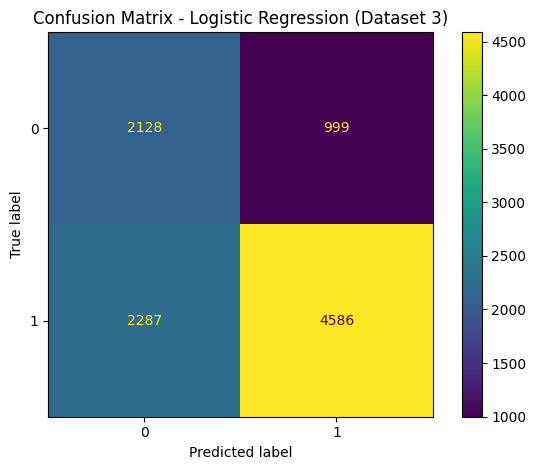


Logistic Regression Results: Dataset 3 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.6652
Mean Precision: 0.8149
Mean Recall   : 0.6637
Mean F1-score : 0.7315

Feature Importance Ranking (Absolute Coefficient Magnitude)
                     Feature  Importance
0                 pack_years    0.508937
1          asbestos_exposure    0.409120
2             copd_diagnosis    0.400392
3                        age    0.314790
4             radon_exposure    0.313512
5             family_history    0.278358
6  secondhand_smoke_exposure    0.253461
7        alcohol_consumption    0.084229
8                     gender    0.000318


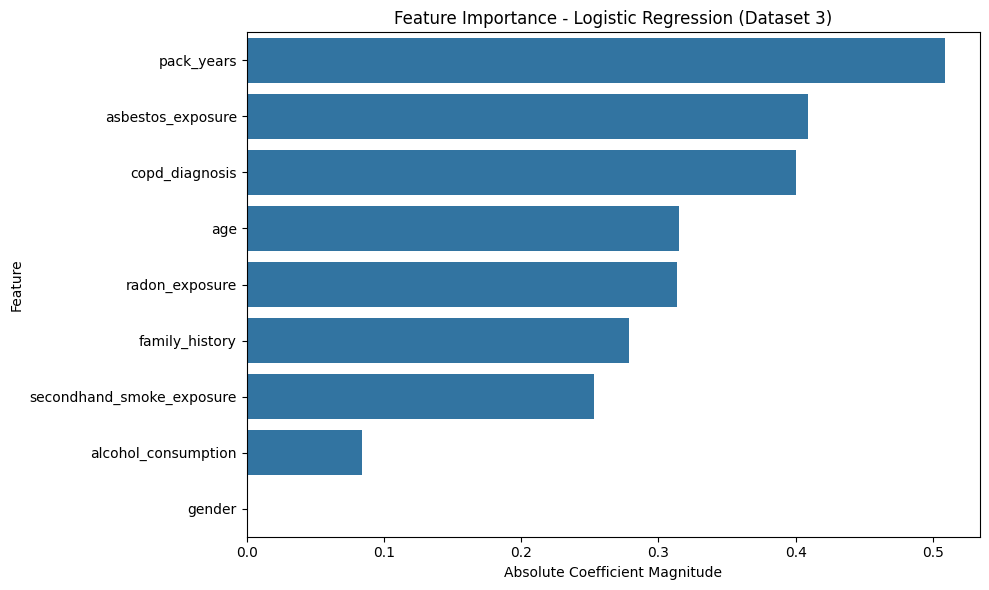


Individual Feature Results (5-Fold CV)
                 Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0             radon_exposure             1   0.59422   0.711196  0.689617   
1        alcohol_consumption             1   0.57288   0.695101  0.674339   
2                 pack_years             1   0.58410   0.757839  0.580288   
3                        age             1   0.56402   0.743599  0.558084   
4             copd_diagnosis             1   0.57168   0.758276  0.553108   
5          asbestos_exposure             1   0.57182   0.760670  0.550052   
6             family_history             1   0.54942   0.736869  0.535706   
7  secondhand_smoke_exposure             1   0.54542   0.732083  0.534018   
8                     gender             1   0.49478   0.682097  0.496188   

   F1-score  
0  0.700229  
1  0.684555  
2  0.657264  
3  0.637616  
4  0.639627  
5  0.638434  
6  0.620373  
7  0.617544  
8  0.574462  

Top-k Feature Combination Results (5-Fold CV)
  

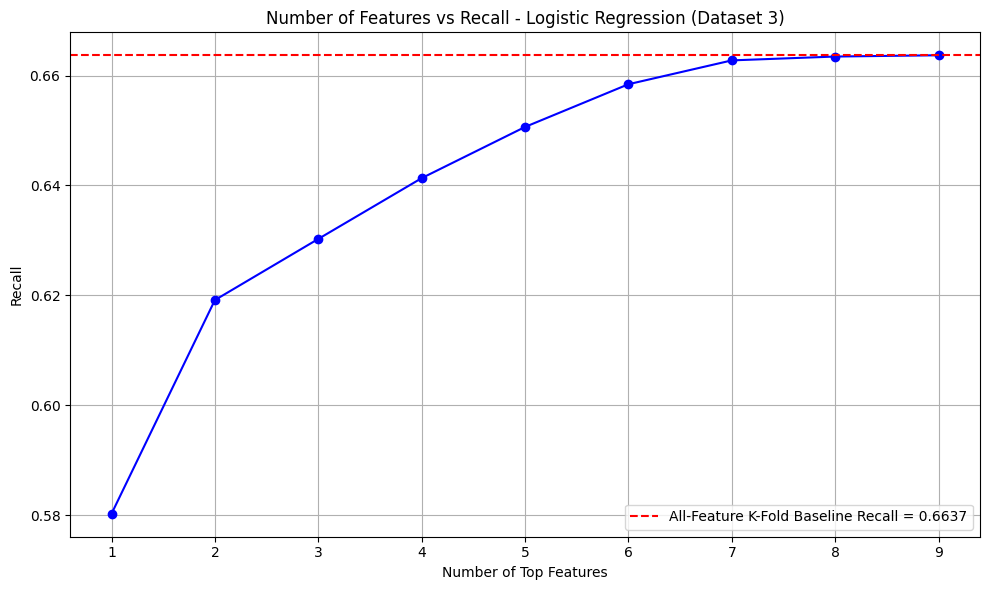

In [10]:
# LOGIC REGRESSION
import sklearn
from sklearn import linear_model
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

print("DATASET 3: Lung Cancer Risk Dataset")

df3_lr = df_Lung_Cancer_Risk_Dataset.copy()

pd.set_option('display.max_columns', None)

# Encode all columns
for col in df3_lr.columns:
    if not pd.api.types.is_numeric_dtype(df3_lr[col]):
        df3_lr[col] = LabelEncoder().fit_transform(df3_lr[col].astype(str))

# Clean column names
df3_lr.columns = df3_lr.columns.str.strip()

print("First 5 rows")
print(df3_lr.head())

print("\nColumn names:")
print(df3_lr.columns.tolist())

print("\nDataset info:")
df3_lr.info()

print("\nMissing values:")
print(df3_lr.isnull().sum())

# DROP ID COLUMN IF IT EXISTS
if "patient_id" in df3_lr.columns:
    df3_lr = df3_lr.drop(columns=["patient_id"])

for col in df3_lr.columns:
    if df3_lr[col].dtype == "object":
        df3_lr[col] = df3_lr[col].fillna(df3_lr[col].median())
    else:
        df3_lr[col] = df3_lr[col].fillna(df3_lr[col].median())

print("\nMissing values after filling:")
print(df3_lr.isnull().sum())

X3 = df3_lr.drop(columns=['lung_cancer'])
y3 = df3_lr['lung_cancer']

# Scale features
scaler3 = StandardScaler()
X3_scaled = scaler3.fit_transform(X3)

# BASELINE MODEL
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)

X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X3_scaled,
    y3,
    test_size=0.2,
    random_state=42
)

model.fit(X_train3, y_train3)

y_pred3 = model.predict(X_test3)

print(classification_report(y_test3, y_pred3))

accuracy_lr = accuracy_score(y_test3, y_pred3)
f1_lr = f1_score(y_test3, y_pred3)
precision_lr = precision_score(y_test3, y_pred3)
recall_lr = recall_score(y_test3, y_pred3)

print(f"\nAccuracy: {accuracy_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")

cm_lr = confusion_matrix(y_test3, y_pred3)

print(cm_lr)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=model.classes_
)
disp.plot()
plt.show()

# BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

baseline_cv_results = cross_validate(
    baseline_model,
    X3_scaled,
    y3,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nLogistic Regression Results: Dataset 3 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE (using coefficients from Logistic Regression)
lr_model_full = LogisticRegression(
    random_state=42,
    class_weight="balanced",
    max_iter=1000
)

lr_model_full.fit(X3_scaled, y3)

# Get absolute coefficients for feature importance
feature_importance_df = pd.DataFrame({
    "Feature": X3.columns,
    "Importance": np.abs(lr_model_full.coef_[0])
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking (Absolute Coefficient Magnitude)")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Logistic Regression (Dataset 3)")
plt.xlabel("Absolute Coefficient Magnitude")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X3[[feature]]

    # Scale the single feature
    scaler_single = StandardScaler()
    X_single_scaled = scaler_single.fit_transform(X_single)

    single_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    )

    single_cv_results = cross_validate(
        single_model,
        X_single_scaled,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X3[selected_features]

    # Scale the top-k features
    scaler_topk = StandardScaler()
    X_topk_scaled = scaler_topk.fit_transform(X_topk)

    topk_model = LogisticRegression(
        random_state=42,
        class_weight="balanced",
        max_iter=1000
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk_scaled,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X3.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o", color="blue")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Logistic Regression (Dataset 3)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# LOGISTIC REGRESSION RESULTS FOR FINAL COMPARISON
lr3_summary = {
    "Model": "Logistic Regression",
    "Accuracy": accuracy_lr,
    "Precision": precision_lr,
    "Recall": recall_lr,
    "F1-score": f1_lr,
    "CV Accuracy": baseline_accuracy_cv,
    "CV Precision": baseline_precision_cv,
    "CV Recall": baseline_recall_cv,
    "CV F1-score": baseline_f1_cv
}

cm_lr3 = cm_lr.copy()
topk_lr3_results_df = topk_results_df.copy()

First 5 rows:
   patient_id  age  gender  pack_years radon_exposure asbestos_exposure  \
0      100000   69    Male   66.025244           High                No   
1      100001   32  Female   12.780800           High                No   
2      100002   89  Female    0.408278         Medium               Yes   
3      100003   78  Female   44.065232            Low                No   
4      100004   38  Female   44.432440         Medium               Yes   

  secondhand_smoke_exposure copd_diagnosis alcohol_consumption family_history  \
0                        No            Yes            Moderate             No   
1                       Yes            Yes            Moderate            Yes   
2                       Yes            Yes                None             No   
3                       Yes             No            Moderate             No   
4                        No            Yes                None            Yes   

  lung_cancer  
0          No  
1         Yes  


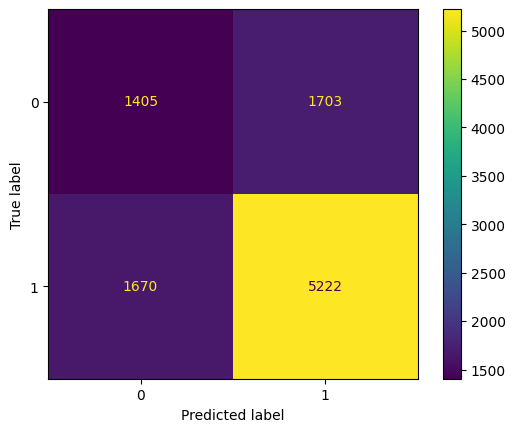


Decision Tree Results: Dataset 3 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.6553
Mean Precision: 0.7469
Mean Recall   : 0.7540
Mean F1-score : 0.7504

Feature Importance Ranking
                     Feature  Importance
0                 pack_years    0.513429
1                        age    0.253518
2        alcohol_consumption    0.052830
3             radon_exposure    0.049010
4                     gender    0.034999
5          asbestos_exposure    0.031295
6             copd_diagnosis    0.029226
7  secondhand_smoke_exposure    0.018625
8             family_history    0.017067


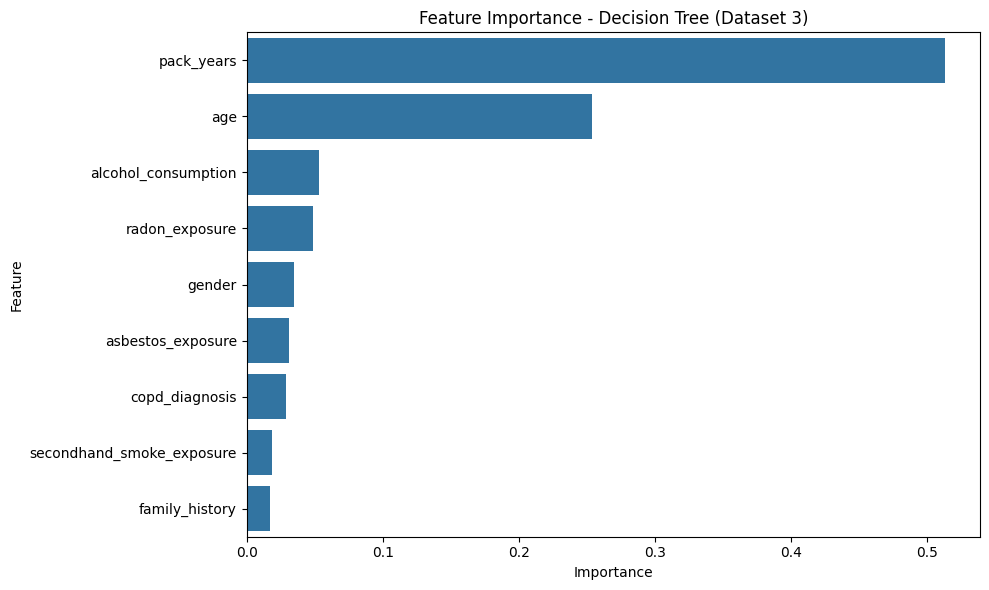


Individual Feature Results (5-Fold CV)
                 Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 pack_years             1   0.61242   0.718060  0.717961   
1                        age             1   0.60398   0.743148  0.647625   
2             copd_diagnosis             1   0.57168   0.758276  0.553108   
3          asbestos_exposure             1   0.57182   0.760670  0.550052   
4             family_history             1   0.54942   0.736869  0.535706   
5  secondhand_smoke_exposure             1   0.54542   0.732083  0.534018   
6                     gender             1   0.49478   0.682097  0.496188   
7             radon_exposure             1   0.49698   0.776887  0.376149   
8        alcohol_consumption             1   0.45400   0.710689  0.346671   

   F1-score  
0  0.718006  
1  0.692101  
2  0.639627  
3  0.638434  
4  0.620373  
5  0.617544  
6  0.574462  
7  0.506861  
8  0.466012  

Top-k Feature Combination Results (5-Fold CV)
  

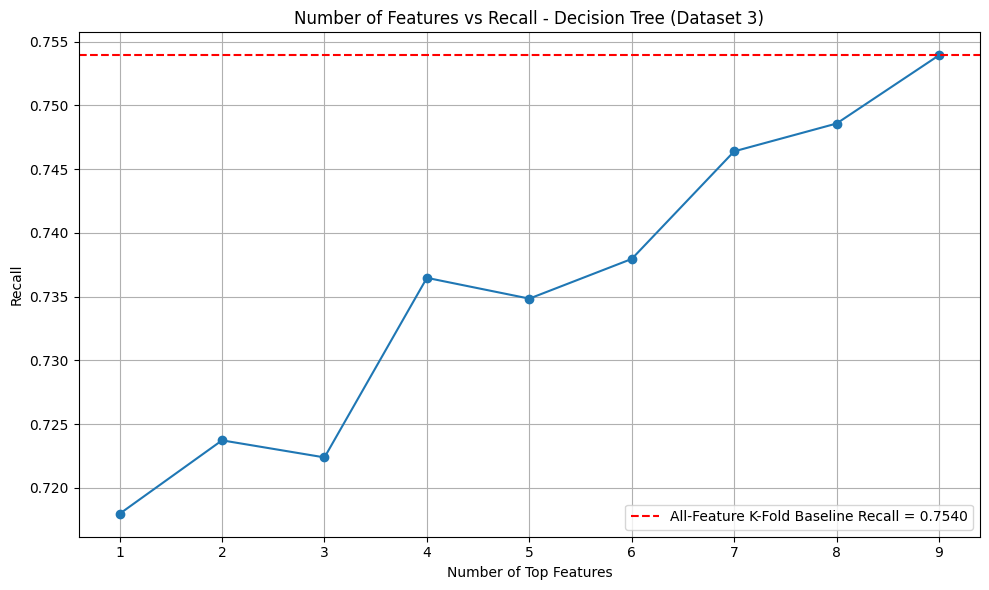

In [8]:
# DECISION TREE
import sklearn
from sklearn import tree #https://scikit-learn.org/stable/modules/tree.html
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import LabelEncoder #https://www.geeksforgeeks.org/machine-learning/encoding-categorical-data-in-sklearn/
import matplotlib.pyplot as plt
import seaborn as sns

# Dataset 3
'''
for col in df_Lung_Cancer_Risk_Dataset.columns:
  df_Lung_Cancer_Risk_Dataset[col] = LabelEncoder().fit_transform(df_Lung_Cancer_Risk_Dataset[col])
'''

df3_dt = df_Lung_Cancer_Risk_Dataset.copy()

# Clean column names
df3_dt.columns = df3_dt.columns.str.strip()

df3_dt['alcohol_consumption'] = df3_dt['alcohol_consumption'].fillna('None')

print("First 5 rows:")
print(df3_dt.head())

print("\nColumn names:")
print(df3_dt.columns.tolist())

print("\nDataset info:")
df3_dt.info()

print("\nMissing values:")
print(df3_dt.isnull().sum())

# DROP ID COLUMN IF IT EXISTS
if "patient_id" in df3_dt.columns:
    df3_dt = df3_dt.drop(columns=["patient_id"])

# FILL MISSING VALUES
for col in df3_dt.columns:
    if df3_dt[col].dtype == "object":
        df3_dt[col] = df3_dt[col].fillna(df3_dt[col].mode()[0])
    else:
        df3_dt[col] = df3_dt[col].fillna(df3_dt[col].median())

print("\nMissing values after filling:")
print(df3_dt.isnull().sum())

#ENCODING
for col in df3_dt.columns:
    if not pd.api.types.is_numeric_dtype(df3_dt[col]):
        df3_dt[col] = LabelEncoder().fit_transform(df3_dt[col].astype(str))


X3 = df3_dt.drop(columns=['lung_cancer'])
y3 = df3_dt['lung_cancer']

#BASELINE MODEL
model = tree.DecisionTreeClassifier(class_weight='balanced')
X_train, X_test, y_train, y_test = train_test_split(X3, y3, test_size=0.2)
model.fit(X_train, y_train)

from sklearn.metrics import classification_report

print(classification_report(y_test, model.predict(X_test)))

print(f"\nAccuracy: {accuracy_score(y_test, model.predict(X_test)):.4f}")

print(f"F1-Score: {f1_score(y_test, model.predict(X_test)):.4f}")

print(f"Precision: {precision_score(y_test, model.predict(X_test)):.4f}")

print(f"Recall: {recall_score(y_test, model.predict(X_test)):.4f}")

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

print(confusion_matrix(y_test, model.predict(X_test)))

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, model.predict(X_test)),
                              display_labels=model.classes_) #https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ConfusionMatrixDisplay.html#sklearn.metrics.ConfusionMatrixDisplay
disp.plot()
plt.show()

# Save 80/20 split results for later comparison
accuracy_dt = accuracy_score(y_test, model.predict(X_test))
precision_dt = precision_score(y_test, model.predict(X_test), zero_division=0)
recall_dt = recall_score(y_test, model.predict(X_test), zero_division=0)
f1_dt = f1_score(y_test, model.predict(X_test), zero_division=0)
cm_dt = confusion_matrix(y_test, model.predict(X_test))

#BASELINE K-FOLD METRICS
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X3,
    y3,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nDecision Tree Results: Dataset 3 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

#FEATURE IMPORTANCE
dt_model_full = tree.DecisionTreeClassifier(
    random_state=42,
    class_weight="balanced"
)

dt_model_full.fit(X3, y3)

feature_importance_df = pd.DataFrame({
    "Feature": X3.columns,
    "Importance": dt_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Decision Tree (Dataset 3)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X3[[feature]]

    single_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X3[selected_features]

    topk_model = tree.DecisionTreeClassifier(
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X3.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Decision Tree (Dataset 3)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# DECISION TREE RESULTS FOR FINAL COMPARISON
dt3_summary = {
    "Model": "Decision Tree",
    "Accuracy": accuracy_dt,
    "Precision": precision_dt,
    "Recall": recall_dt,
    "F1-score": f1_dt,
    "CV Accuracy": baseline_accuracy_cv,
    "CV Precision": baseline_precision_cv,
    "CV Recall": baseline_recall_cv,
    "CV F1-score": baseline_f1_cv
}

cm_dt3 = cm_dt.copy()
topk_dt3_results_df = topk_results_df.copy()

First 5 rows:
   patient_id  age  gender  pack_years radon_exposure asbestos_exposure  \
0      100000   69    Male   66.025244           High                No   
1      100001   32  Female   12.780800           High                No   
2      100002   89  Female    0.408278         Medium               Yes   
3      100003   78  Female   44.065232            Low                No   
4      100004   38  Female   44.432440         Medium               Yes   

  secondhand_smoke_exposure copd_diagnosis alcohol_consumption family_history  \
0                        No            Yes            Moderate             No   
1                       Yes            Yes            Moderate            Yes   
2                       Yes            Yes                None             No   
3                       Yes             No            Moderate             No   
4                        No            Yes                None            Yes   

  lung_cancer  
0          No  
1         Yes  


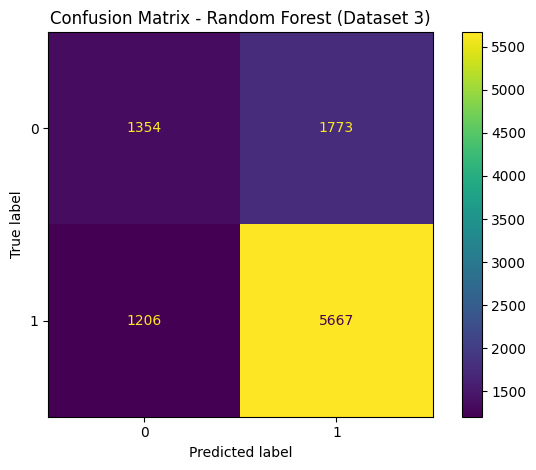


Random Forest Results: Dataset 3 (5-Fold CV Baseline - All Features)
Mean Accuracy : 0.7024
Mean Precision: 0.7582
Mean Recall   : 0.8324
Mean F1-score : 0.7936

Feature Importance Ranking
                     Feature  Importance
0                 pack_years    0.482203
1                        age    0.305177
2             radon_exposure    0.044425
3        alcohol_consumption    0.041223
4          asbestos_exposure    0.032274
5             copd_diagnosis    0.031799
6                     gender    0.021988
7             family_history    0.021084
8  secondhand_smoke_exposure    0.019828


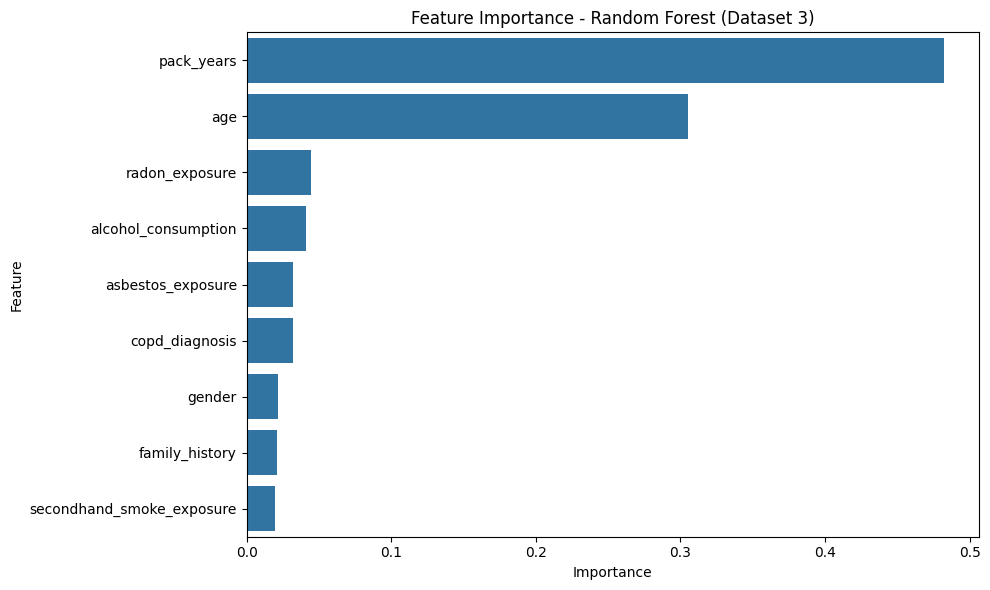


Individual Feature Results (5-Fold CV)
                 Feature_Set  Num_Features  Accuracy  Precision    Recall  \
0                 pack_years             1   0.61264   0.718176  0.718223   
1                        age             1   0.60398   0.743148  0.647625   
2                     gender             1   0.53286   0.682118  0.597803   
3             copd_diagnosis             1   0.57168   0.758276  0.553108   
4          asbestos_exposure             1   0.57182   0.760670  0.550052   
5             family_history             1   0.54942   0.736869  0.535706   
6  secondhand_smoke_exposure             1   0.54542   0.732083  0.534018   
7             radon_exposure             1   0.49698   0.776887  0.376149   
8        alcohol_consumption             1   0.45400   0.710689  0.346671   

   F1-score  
0  0.718195  
1  0.692101  
2  0.622719  
3  0.639627  
4  0.638434  
5  0.620373  
6  0.617544  
7  0.506861  
8  0.466012  

Top-k Feature Combination Results (5-Fold CV)
  

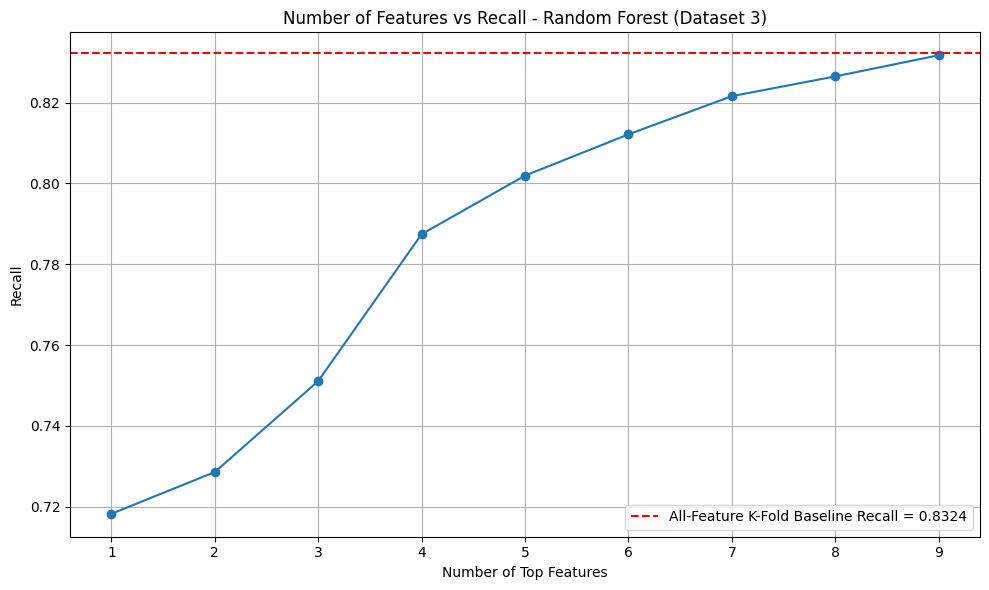

In [9]:
# RANDOM FOREST
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder

df3_rf = df_Lung_Cancer_Risk_Dataset.copy()

# Clean column names
df3_rf.columns = df3_rf.columns.str.strip()

# Keep alcohol_consumption consistent with the original keep_default_na=False import
if "alcohol_consumption" in df3_rf.columns:
    df3_rf["alcohol_consumption"] = df3_rf["alcohol_consumption"].fillna("None")

print("First 5 rows:")
print(df3_rf.head())

print("\nColumn names:")
print(df3_rf.columns.tolist())

print("\nDataset info:")
df3_rf.info()

print("\nMissing values:")
print(df3_rf.isnull().sum())

# DROP ID COLUMN IF IT EXISTS
if "patient_id" in df3_rf.columns:
    df3_rf = df3_rf.drop(columns=["patient_id"])

# FILL MISSING VALUES
for col in df3_rf.columns:
    if df3_rf[col].dtype == "object":
        df3_rf[col] = df3_rf[col].fillna(df3_rf[col].mode()[0])
    else:
        df3_rf[col] = df3_rf[col].fillna(df3_rf[col].median())

print("\nMissing values after filling:")
print(df3_rf.isnull().sum())

# ENCODE CATEGORICAL VARIABLES
label_encoders = {}

for col in df3_rf.columns:
    if df3_rf[col].dtype == "object":
        le = LabelEncoder()
        df3_rf[col] = le.fit_transform(df3_rf[col].astype(str))
        label_encoders[col] = le

# DEFINE TARGET AND FEATURES
target_col = "lung_cancer"
X3 = df3_rf.drop(columns=[target_col])
y3 = df3_rf[target_col]

print("\nClass distribution:")
print(y3.value_counts())

print("\nClass distribution (proportion):")
print(y3.value_counts(normalize=True))

# ORIGINAL TRAIN-TEST BASELINE
X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3,
    y3,
    test_size=0.2,
    random_state=42,
    stratify=y3
)

rf_model_split = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_split.fit(X3_train, y3_train)
y3_pred = rf_model_split.predict(X3_test)

accuracy_3 = accuracy_score(y3_test, y3_pred)
precision_3 = precision_score(y3_test, y3_pred, zero_division=0)
recall_3 = recall_score(y3_test, y3_pred, zero_division=0)
f1_3 = f1_score(y3_test, y3_pred, zero_division=0)

print("\nRandom Forest Results: Dataset 3 (80/20 Split Baseline)")
print(f"Accuracy : {accuracy_3:.4f}")
print(f"Precision: {precision_3:.4f}")
print(f"Recall   : {recall_3:.4f}")
print(f"F1-score : {f1_3:.4f}")

cm3 = confusion_matrix(y3_test, y3_pred)

print("\nConfusion Matrix:")
print(cm3)

disp = ConfusionMatrixDisplay(confusion_matrix=cm3)
disp.plot()
plt.title("Confusion Matrix - Random Forest (Dataset 3)")
plt.tight_layout()
plt.show()

# K-FOLD BASELINE
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

baseline_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

baseline_cv_results = cross_validate(
    baseline_model,
    X3,
    y3,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

baseline_accuracy_cv = baseline_cv_results["test_accuracy"].mean()
baseline_precision_cv = baseline_cv_results["test_precision"].mean()
baseline_recall_cv = baseline_cv_results["test_recall"].mean()
baseline_f1_cv = baseline_cv_results["test_f1"].mean()

print("\nRandom Forest Results: Dataset 3 (5-Fold CV Baseline - All Features)")
print(f"Mean Accuracy : {baseline_accuracy_cv:.4f}")
print(f"Mean Precision: {baseline_precision_cv:.4f}")
print(f"Mean Recall   : {baseline_recall_cv:.4f}")
print(f"Mean F1-score : {baseline_f1_cv:.4f}")

# FEATURE IMPORTANCE
rf_model_full = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_model_full.fit(X3, y3)

feature_importance_df = pd.DataFrame({
    "Feature": X3.columns,
    "Importance": rf_model_full.feature_importances_
}).sort_values(by="Importance", ascending=False).reset_index(drop=True)

print("\nFeature Importance Ranking")
print(feature_importance_df)

plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x="Importance", y="Feature")
plt.title("Feature Importance - Random Forest (Dataset 3)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

# INDIVIDUAL FEATURE EXPERIMENTS
individual_feature_results = []

for feature in feature_importance_df["Feature"]:
    X_single = X3[[feature]]

    single_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    single_cv_results = cross_validate(
        single_model,
        X_single,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    individual_feature_results.append({
        "Feature_Set": feature,
        "Num_Features": 1,
        "Accuracy": single_cv_results["test_accuracy"].mean(),
        "Precision": single_cv_results["test_precision"].mean(),
        "Recall": single_cv_results["test_recall"].mean(),
        "F1-score": single_cv_results["test_f1"].mean()
    })

individual_feature_df = pd.DataFrame(individual_feature_results).sort_values(
    by="Recall",
    ascending=False
).reset_index(drop=True)

print("\nIndividual Feature Results (5-Fold CV)")
print(individual_feature_df)

# TOP-K FEATURE COMBINATION EXPERIMENTS
ranked_features = feature_importance_df["Feature"].tolist()
topk_results = []

for k in range(1, len(ranked_features) + 1):
    selected_features = ranked_features[:k]
    X_topk = X3[selected_features]

    topk_model = RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    )

    topk_cv_results = cross_validate(
        topk_model,
        X_topk,
        y3,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    topk_results.append({
        "Num_Features": k,
        "Features_Used": ", ".join(selected_features),
        "Accuracy": topk_cv_results["test_accuracy"].mean(),
        "Precision": topk_cv_results["test_precision"].mean(),
        "Recall": topk_cv_results["test_recall"].mean(),
        "F1-score": topk_cv_results["test_f1"].mean()
    })

topk_results_df = pd.DataFrame(topk_results)

print("\nTop-k Feature Combination Results (5-Fold CV)")
print(topk_results_df)

# OFFICIAL K-FOLD BASELINE FOR COMPARISON
baseline_row = pd.DataFrame([{
    "Num_Features": X3.shape[1],
    "Features_Used": "All Features (Official Baseline)",
    "Accuracy": baseline_accuracy_cv,
    "Precision": baseline_precision_cv,
    "Recall": baseline_recall_cv,
    "F1-score": baseline_f1_cv
}])

print("\nOfficial K-Fold Baseline for Comparison")
print(baseline_row)

# PLOT: NUMBER OF FEATURES VS RECALL
plt.figure(figsize=(10, 6))
plt.plot(topk_results_df["Num_Features"], topk_results_df["Recall"], marker="o")
plt.axhline(
    y=baseline_recall_cv,
    color="red",
    linestyle="--",
    label=f"All-Feature K-Fold Baseline Recall = {baseline_recall_cv:.4f}"
)
plt.title("Number of Features vs Recall - Random Forest (Dataset 3)")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, len(ranked_features) + 1))
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# RANDOM FOREST RESULTS FOR FINAL COMPARISON
rf3_summary = {
    "Model": "Random Forest",
    "Accuracy": accuracy_3,
    "Precision": precision_3,
    "Recall": recall_3,
    "F1-score": f1_3,
    "CV Accuracy": baseline_accuracy_cv,
    "CV Precision": baseline_precision_cv,
    "CV Recall": baseline_recall_cv,
    "CV F1-score": baseline_f1_cv
}

cm_rf3 = cm3.copy()
topk_rf3_results_df = topk_results_df.copy()

In [11]:
# FINAL MODEL COMPARISON - DATASET 3

model_comparison_dataset3_df = pd.DataFrame([
    lr3_summary,
    dt3_summary,
    rf3_summary
])

print("Model Performance on Test Data - Dataset 3")
display(model_comparison_dataset3_df[[
    "Model",
    "Accuracy",
    "Precision",
    "Recall",
    "F1-score"
]])

print("\n5-Fold Cross-Validation Performance - Dataset 3")
display(model_comparison_dataset3_df[[
    "Model",
    "CV Accuracy",
    "CV Precision",
    "CV Recall",
    "CV F1-score"
]])

Model Performance on Test Data - Dataset 3


,Model,Accuracy,Precision,Recall,F1-score
0,Logistic Regression,0.6714,0.821128,0.667249,0.736234
1,Decision Tree,0.6627,0.754079,0.757690,0.755880
2,Random Forest,0.7021,0.761694,0.824531,0.791868



5-Fold Cross-Validation Performance - Dataset 3


,Model,CV Accuracy,CV Precision,CV Recall,CV F1-score
0,Logistic Regression,0.66524,0.814895,0.663689,0.731538
1,Decision Tree,0.65534,0.746942,0.753958,0.750423
2,Random Forest,0.70236,0.758204,0.832383,0.793562


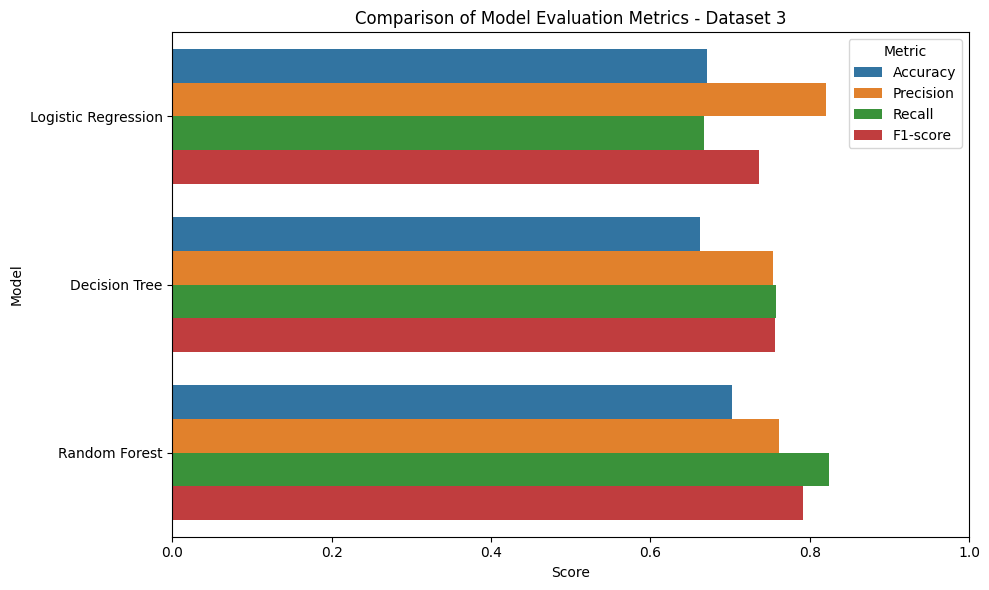

In [12]:
# BAR CHART: MODEL EVALUATION METRICS - DATASET 3

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-score"]

model_comparison_dataset3_long = model_comparison_dataset3_df.melt(
    id_vars="Model",
    value_vars=metrics_to_plot,
    var_name="Metric",
    value_name="Score"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=model_comparison_dataset3_long,
    x="Score",
    y="Model",
    hue="Metric"
)

plt.title("Comparison of Model Evaluation Metrics - Dataset 3")
plt.xlabel("Score")
plt.ylabel("Model")
plt.xlim(0, 1)
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

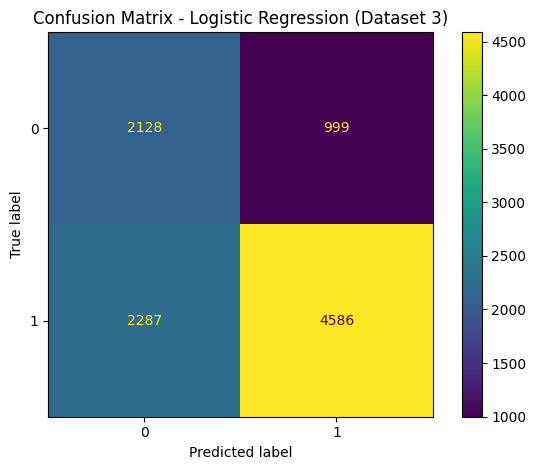

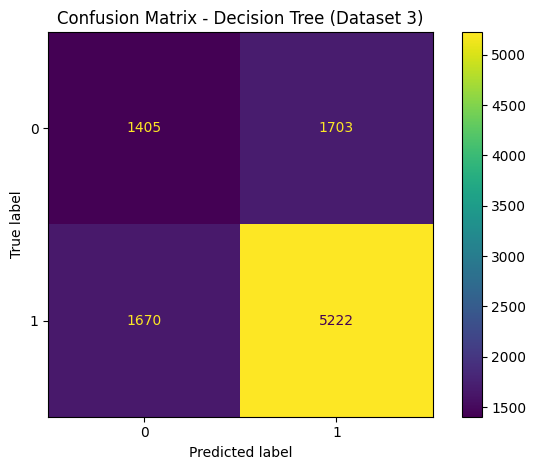

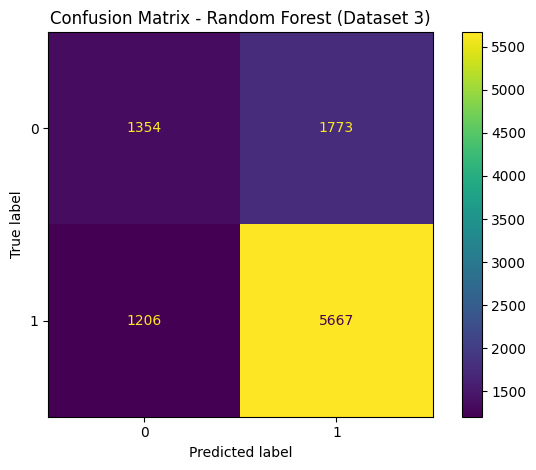

In [14]:
# CONFUSION MATRICES FOR EACH MODEL - DATASET 3

confusion_matrices_dataset3 = {
    "Logistic Regression": cm_lr3,
    "Decision Tree": cm_dt3,
    "Random Forest": cm_rf3
}

for model_name, matrix in confusion_matrices_dataset3.items():
    disp = ConfusionMatrixDisplay(
        confusion_matrix=matrix,
        display_labels=[0, 1]
    )
    disp.plot()
    plt.title(f"Confusion Matrix - {model_name} (Dataset 3)")
    plt.tight_layout()
    plt.show()

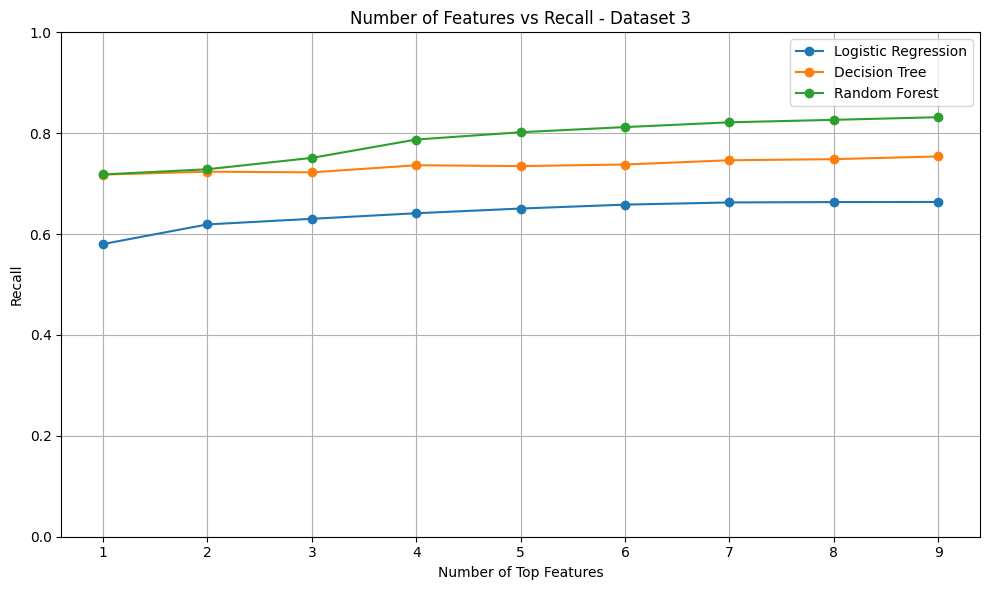

In [15]:
# FINAL GRAPH: NUMBER OF FEATURES VS RECALL FOR ALL MODELS - DATASET 3

plt.figure(figsize=(10, 6))

plt.plot(
    topk_lr3_results_df["Num_Features"],
    topk_lr3_results_df["Recall"],
    marker="o",
    label="Logistic Regression"
)

plt.plot(
    topk_dt3_results_df["Num_Features"],
    topk_dt3_results_df["Recall"],
    marker="o",
    label="Decision Tree"
)

plt.plot(
    topk_rf3_results_df["Num_Features"],
    topk_rf3_results_df["Recall"],
    marker="o",
    label="Random Forest"
)

max_features = max(
    topk_lr3_results_df["Num_Features"].max(),
    topk_dt3_results_df["Num_Features"].max(),
    topk_rf3_results_df["Num_Features"].max()
)

plt.title("Number of Features vs Recall - Dataset 3")
plt.xlabel("Number of Top Features")
plt.ylabel("Recall")
plt.xticks(range(1, max_features + 1))
plt.ylim(0, 1)
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()